In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("cleaned_data.csv")
df = df.drop("normalized", axis=1)
df_copy = df.copy()

In [61]:
df_head = df.head()
df.columns
df.describe()

,Salary Estimate,Rating,Size,Founded,Revenue,Competitors,SQL,R,Python,Excel,Tableau,SAS,spark,aws
count,956.000000,956.000000,956.000000,956.000000,956.000000,956.00000,956.000000,956.000000,956.000000,956.000000,956.000000,956.000000,956.000000,956.000000
mean,101.433598,3.601255,4.014644,45.624477,5.000000,0.33682,0.483264,0.374477,0.514644,0.173640,0.196653,0.100418,0.208159,0.169456
std,33.072918,1.067619,2.009870,50.866134,4.845033,0.47287,0.499981,0.484241,0.500047,0.378998,0.397676,0.300714,0.406204,0.375351
min,15.500000,-1.000000,-1.000000,-1.000000,-1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,81.000000,3.300000,2.000000,15.000000,-1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,101.430000,3.800000,4.000000,27.000000,6.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,114.000000,4.200000,5.000000,58.000000,9.000000,1.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,254.000000,5.000000,7.000000,282.000000,12.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# 1. Define the list of columns you want to remove the -1
cols = ["Salary Estimate", "Size", "Founded", "Revenue", "Rating"]
# 2. Filter the DataFrame: keep rows where ALL selected columns are NOT -1
df_filtered = df[cols][(df[cols] != -1).all(axis=1)]

array([[<Axes: title={'center': 'Rating'}>]], dtype=object)

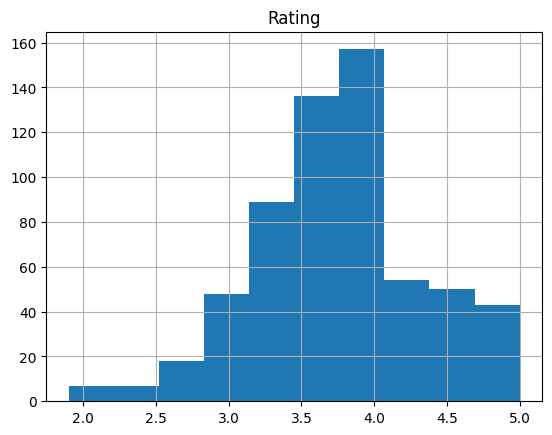

In [63]:
df_filtered.loc[df["Rating"] != -1, ["Rating"]].hist()

<Axes: >

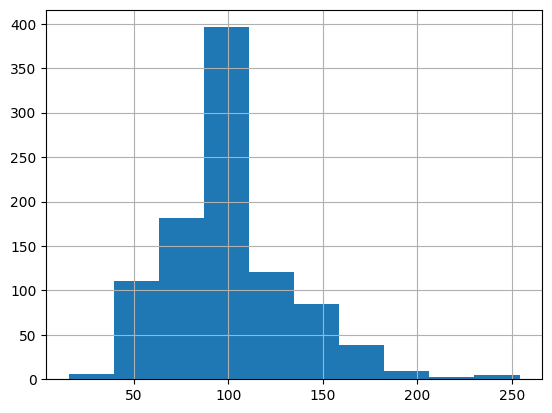

In [64]:
df["Salary Estimate"].hist()

<Axes: >

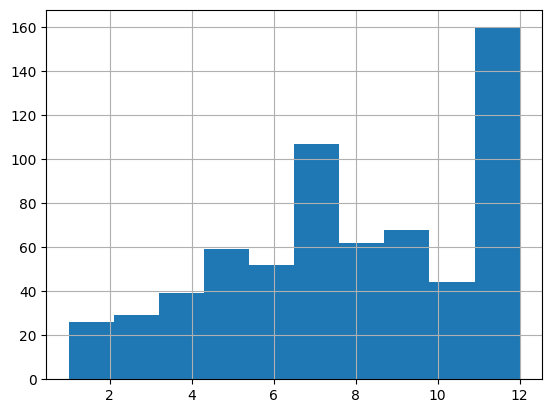

In [65]:
df.loc[df["Revenue"] != -1, "Revenue"].hist()

<Axes: >

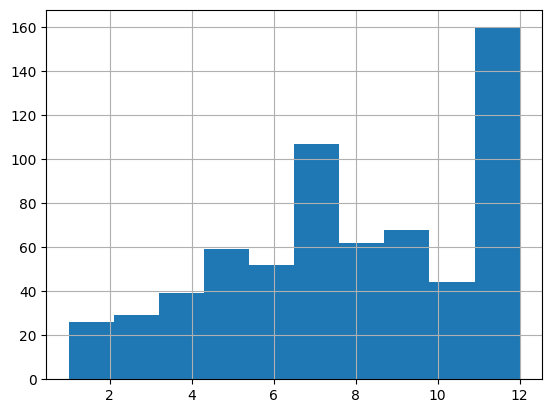

In [ ]:
df.loc[df["Revenue"] != -1, "Revenue"].hist()
# Exponetial distribution

<Axes: >

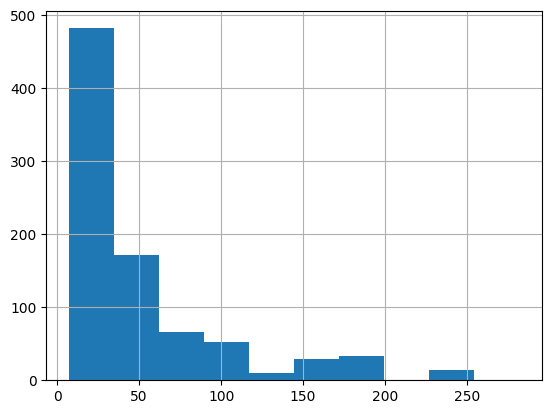

In [67]:
df.loc[df["Founded"] != -1, "Founded"].hist()
# Exponetial distribution

<Axes: >

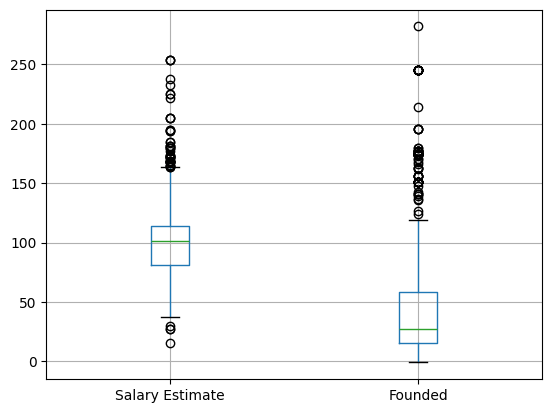

In [ ]:
df.boxplot(column=["Salary Estimate", "Founded"])

In [69]:
# Corelation Salary Estimate, Size , Founded, Revenue
df[["Salary Estimate", "Size", "Founded", "Revenue"]].corr()

,Salary Estimate,Size,Founded,Revenue
Salary Estimate,1.000000,-0.009624,0.020305,-0.000612
Size,-0.009624,1.000000,0.542141,0.665937
Founded,0.020305,0.542141,1.000000,0.573051
Revenue,-0.000612,0.665937,0.573051,1.000000


<Axes: >

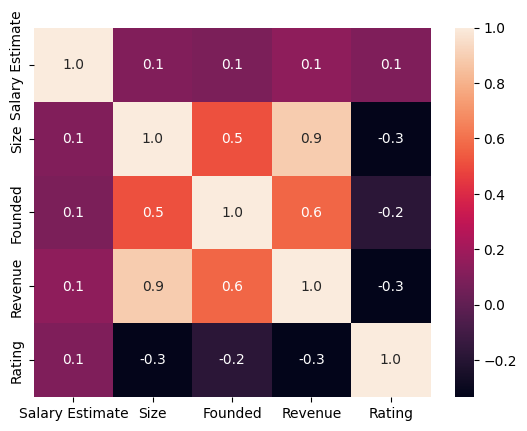

In [ ]:
# 1. Create the heatmap using the filtered data
sns.heatmap(df_filtered.corr(), annot=True, fmt=".1f")

""" The conclusion:
        # Size vs. Revenue (0.9): This is a very strong positive correlation. 
        It indicates that as the company size increases (likely measured by headcount), the company's revenue tends to increase as well.

        Revenue vs. Founded (0.6): There is a moderate positive correlation here. This suggests that older companies 
        (higher "Founded" year values usually imply more recent, so you should check if this column is "Year Founded" or "Company Age") generally report higher revenue.

        Size vs. Founded (0.5): A moderate positive correlation, suggesting newer companies (if higher values = more recent years) might be scaling differently, 
        or simply that size and age often grow together.
        """

<Axes: >

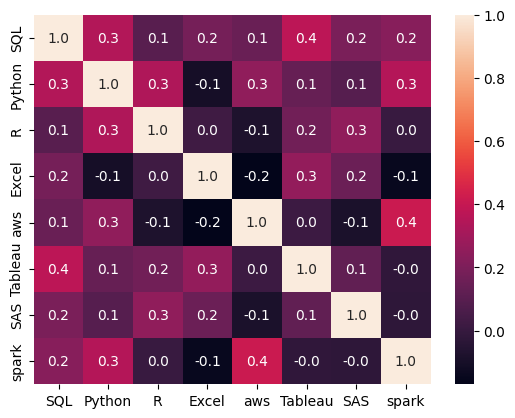

In [ ]:
sns.heatmap(
    df[["SQL", "Python", "R", "Excel", "aws", "Tableau", "SAS", "spark"]].corr(),
    annot=True,
    fmt=".1f",
)

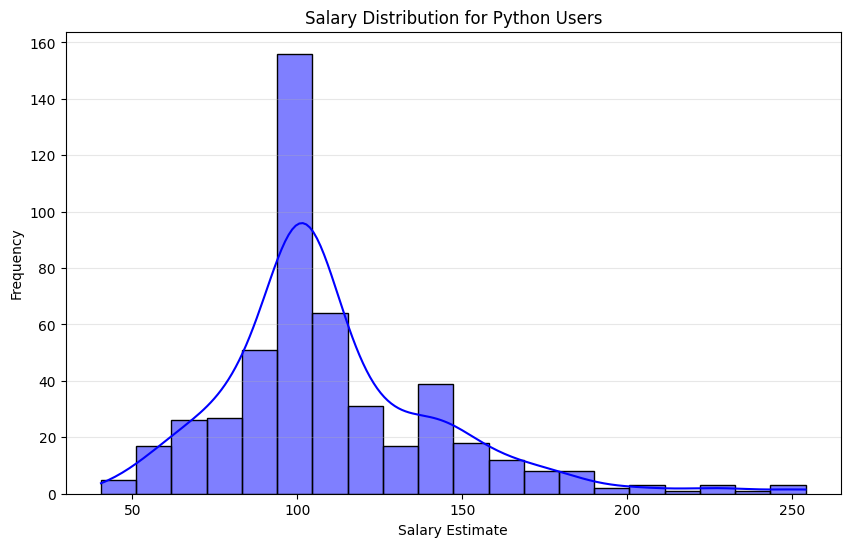

In [ ]:
# 1. Filter: Keep only rows where Python is 1 AND Salary is not -1
python_users_salary = df[(df["Python"] == 1) & (df["Salary Estimate"] != -1)]["Salary Estimate"]

# 2. Create the plot
plt.figure(figsize=(10, 6))
sns.histplot(python_users_salary, kde=True, color="blue", bins=20)

# 3. Add labels
plt.title("Salary Distribution for Python Users")
plt.xlabel("Salary Estimate")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.show()